# Exercise 4
### Computer Vision, Fall 2025
#### Name: <font color='blue'>*Chiara Zara*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Sunday Oct. 05 at 23.50</font> via Moodle.


## Ex 4.1. Epipolar Geometry (4 p)
1. In your own words, explain the following terms:
   - Epipole
   - Epipolar line
   - Epipolar plane
2.  Explain what the epipolar constraint is. Why does a point in one image have a corresponding geometric relationship with the epipolar line in the other view?
3.  In simple terms, describe the role of the fundamental matrix **F**. Why is it important in epipolar geometry, and how does it relate two camera views?


#### Answer 
1.
- **Epipole:** The epipole is the point where the line connecting the two camera centres, called the *baseline*, meets the image plane. It can also be seen as the projection of one camera centre onto the other camera’s image. All epipolar lines in an image pass through the epipole, and it represents the direction of the translation between the cameras.
- **Epipolar line:** The epipolar line is formed where the epipolar plane cuts the image plane. For a given point in one image, its matching point in the other image must lie on this line. Therefore, instead of searching across the entire image, the correspondence search can be limited to the epipolar line.
- **Epipolar plane:** The epipolar plane is the plane that contains both camera centres (the baseline) and a 3D point in the scene. As the 3D point changes position, this plane rotates around the baseline, forming a family of planes called the *epipolar pencil*. Each of these planes defines a pair of corresponding epipolar lines in the two images.

2. The epipolar constraint means that for a point in one image, its corresponding point in the other image must lie on a specific epipolar line. This happens because the two camera centres, the 3D point, and their image projections are all located on the same epipolar plane.
When this plane intersects the second image plane, it creates the epipolar line. This geometric relationship helps reduce the search for correspondences to a single line instead of the whole image, making stereo matching more efficient.

3. The fundamental matrix $F$ is the algebraic representation of epipolar geometry.  
It expresses the relationship between a point in one image and the corresponding epipolar line in the other image.  
Mathematically, this is written as:T

$$
x'^T F x = 0
$$

which means that the point $x'$ in the second image lies on the epipolar line related to the point $x$ in the first image.
The fundamental matrix is important because it provides a complete description of the epipolar geometry between two images; it contains all the   information about the relative position and orientation of the two cameras and It allows us to link the geometry of two views without knowing the internal parameters of the cameras.  
   



## Ex 4.2. 8-Point Algorithm (4 p)
In this task you are given two images ("Corridor1.jpg" and "Corridor2.jpg").

1. Detect and match features from those images using OpenCv's SIFT detector and OpenCV's BFFMatcher (https://docs.opencv.org/3.4/da/df5/tutorial_py_sift_intro.html and https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)
2. Implement the 8-point algorithm and compute the fundamental matrix. Normalize the 2d points before running the 8-point algorithm.
3. Validate your results by drawing epipolar lines on image 2 and verify that corresponding points lie on these lines. Explain why this happens.

You can find more resources on epipolar geometry in the course book “Multiple View Geometry in computer vision” by R. Hartley and A. Zisserman.


estimated fundamental matrix F:
 [[ 2.86763766e-07  2.45212463e-05 -3.95893049e-03]
 [-2.40777316e-05 -7.40526159e-07  1.40843593e-02]
 [ 1.87588386e-03 -1.35014213e-02  9.99800055e-01]]
epipolar distances (px): mean=14.218, std=56.144, max=685.801


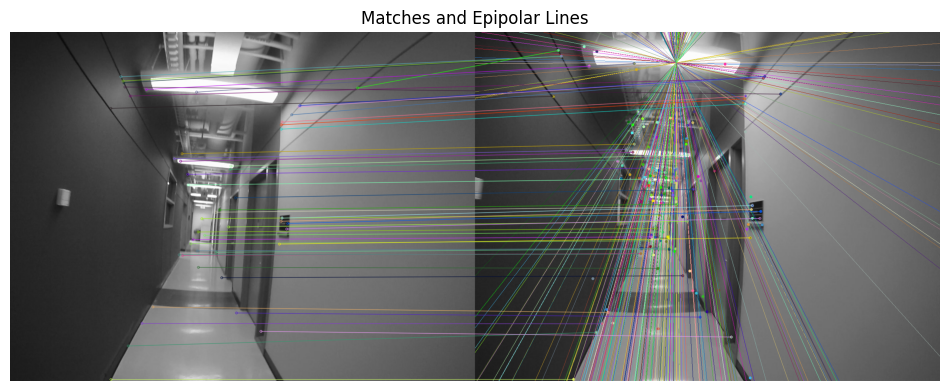

In [3]:
#1)
import cv2
import numpy as np
import matplotlib.pyplot as plt

#images in grayscale
img1 = cv2.imread('Corridor1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('Corridor2.jpg', cv2.IMREAD_GRAYSCALE)

# 1) detect sift features and compute descriptors
# sift detects keypoints (corners, blobs, edges) and gives a descriptor vector for each
sift = cv2.SIFT_create()
kps1, des1 = sift.detectAndCompute(img1, None)  # keypoints and descriptors for image 1
kps2, des2 = sift.detectAndCompute(img2, None)  # keypoints and descriptors for image 2

# 2) match features using bfmatcher and the ratio test
# bfmatcher: brute-force, tries to find nearest neighbor in descriptor space
bf = cv2.BFMatcher(cv2.NORM_L2)
raw_matches = bf.knnMatch(des1, des2, k=2)  # find 2 nearest neighbors

good_matches = []
ratio_thresh = 0.75  # lowe's ratio test threshold
for m, n in raw_matches:
    if m.distance < ratio_thresh * n.distance:
        #keep match only if best match is significantly better than second best
        good_matches.append(m)

#check if we have enough matches for the 8-point algorithm
if len(good_matches) < 8:
    raise RuntimeError(f"not enough good matches found ({len(good_matches)}), need at least 8")

#sort matches by distance (best first) and keep top 200 for stability
good_matches = sorted(good_matches, key=lambda x: x.distance)[:200]

#extract the coordinates of matched keypoints
pts1 = np.array([kps1[m.queryIdx].pt for m in good_matches], dtype=np.float64)
pts2 = np.array([kps2[m.trainIdx].pt for m in good_matches], dtype=np.float64)

#helper function to normalize 2d points
#normalization is important to make the 8-point algorithm stable
def normalize_points(pts):
    pts = pts.astype(np.float64)
    centroid = pts.mean(axis=0)  # compute mean point
    centered = pts - centroid
    mean_dist = np.mean(np.sqrt(np.sum(centered**2, axis=1)))
    scale = np.sqrt(2) / mean_dist if mean_dist > 0 else 1.0  # avoid divide by zero

    #transformation matrix
    T = np.array([[scale, 0, -scale*centroid[0]],
                  [0, scale, -scale*centroid[1]],
                  [0, 0, 1]])
    
    #convert points to homogeneous coordinates
    ones = np.ones((pts.shape[0], 1))
    pts_h = np.hstack([pts, ones])
    
    # apply transformation
    pts_norm_h = (T @ pts_h.T).T
    pts_norm = pts_norm_h[:, :2] / pts_norm_h[:, 2:3]  # back to 2d
    return pts_norm, T

# 3)normalized 8-point algorithm
def eight_point_normalized(pts1, pts2):
    #compute fundamental matrix F using normalized 8-point algorithm pts1, pts2: Nx2 arrays of corresponding points
    if pts1.shape[0] < 8:
        raise ValueError("need at least 8 points for the 8-point algorithm")
    
    #first normalize the points
    npts1, T1 = normalize_points(pts1)
    npts2, T2 = normalize_points(pts2)
    N = npts1.shape[0]

    #build design matrix A where Af=0
    #each row: [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1]
    A = np.zeros((N, 9))
    x1, y1 = npts1[:, 0], npts1[:, 1]
    x2, y2 = npts2[:, 0], npts2[:, 1]
    A[:, 0] = x2 * x1
    A[:, 1] = x2 * y1
    A[:, 2] = x2
    A[:, 3] = y2 * x1
    A[:, 4] = y2 * y1
    A[:, 5] = y2
    A[:, 6] = x1
    A[:, 7] = y1
    A[:, 8] = 1

    # solve Af=0 using SVD
    _, _, Vt = np.linalg.svd(A)
    F_norm = Vt[-1].reshape(3, 3)  # take last row of V as solution

    #enforce rank-2 constraint on F
    U, S, Vt = np.linalg.svd(F_norm)
    S[2] = 0  # smallest singular value = 0
    F_norm_rank2 = U @ np.diag(S) @ Vt

    #denormalize
    F = T2.T @ F_norm_rank2 @ T1
    F /= np.linalg.norm(F)  # optional normalization
    return F

#compute fundamental matrix
F = eight_point_normalized(pts1, pts2)
print("estimated fundamental matrix F:\n", F)

# 4)validate by drawing epipolar lines in image2 for points from image1
#cv2.computeCorrespondEpilines expects pts in shape (N,1,2)
pts1_for_cv = pts1.reshape(-1, 1, 2).astype(np.float32)
lines_in_2 = cv2.computeCorrespondEpilines(pts1_for_cv, 1, F).reshape(-1, 3)

#convert images to color to draw colored lines
img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)

def draw_lines(img, lines, pts):
    #draw epipolar lines and the corresponding points
    for (a, b, c_line), (x, y) in zip(lines, pts):
        if abs(b) > 1e-6:
            #line is not vertical, compute y for x=0 and x=width-1
            pt1 = (0, int(round(-c_line / b)))
            pt2 = (img.shape[1]-1, int(round((-c_line - a*(img.shape[1]-1)) / b)))
        else:
            #vertical-ish line
            x0 = int(round(-c_line / a))
            pt1, pt2 = (x0, 0), (x0, img.shape[0]-1)
        color = tuple(int(v) for v in np.random.randint(0, 255, 3))
        cv2.line(img, pt1, pt2, color, 1)  # draw line
        cv2.circle(img, (int(round(x)), int(round(y))), 4, color, -1)  # draw point

draw_lines(img2_color, lines_in_2, pts2)

#distances of points to epipolar lines (small distance = good F)
dists = [abs(a*x + b*y + c) / np.sqrt(a*a + b*b)
         for (a, b, c), (x, y) in zip(lines_in_2, pts2)]
print(f"epipolar distances (px): mean={np.mean(dists):.3f}, std={np.std(dists):.3f}, max={np.max(dists):.3f}")

#show matches and epipolar lines
match_img = cv2.drawMatches(img1_color, kps1, img2_color, kps2,
                            good_matches[:50], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Matches and Epipolar Lines")
plt.axis('off')
plt.show()


#### Answer/Comment
The corresponding points in image 2 lie on their epipolar lines because the fundamental matrix $F$ encodes the epipolar geometry between the two images. Each point $x_1$ in image 1 defines an epipolar line $l_2 = F x_1$ in image 2, and the true corresponding point $x_2$ should satisfy $x_2^T l_2 = x_2^T F x_1 = 0$. This geometric relationship ensures that for ideal, noise-free points, each correspondence lies exactly on its epipolar line.  

In my specific case, some points do not lie exactly on their epipolar lines because $F$ is estimated from noisy keypoints. Possible reasons include small errors in SIFT detection, incorrect matches (outliers), a limited or uneven number of points, and real-world deviations like lens distortion. In my case, the output shows a mean epipolar distance of 14.218 px, which indicates that most points fit well on their lines, but the high maximum distance of 685.801 px highlights a few outliers (as we can also see from the immage).
